# Sentiment Analysis Review Produk Kategori Makanan dan Minuman Menggunakan IndoBERT
**Deskripsi Proyek:** Proyek ini bertujuan membangun model Sentiment Analysis pada ulasan produk kategori makanan dan minuman menggunakan model IndoBERT (indobenchmark/indobert-base-p1) untuk mengklasifikasikan sentimen menjadi tiga kelas, yaitu positif, netral, dan negatif. Tahapan yang dilakukan meliputi Exploratory Data Analysis (EDA), preprocessing teks tanpa menggunakan Sastrawi, pelabelan menggunakan target asli dataset, tokenisasi, pelatihan model menggunakan class weight, evaluasi performa menggunakan Accuracy, Macro F1, Weighted F1, Error Analysis, Inference, serta penyimpanan model ke format .pkl. Model terbaik menggunakan learning rate 2e-5, batch size 16, epoch 5, dan warmup step 300 dengan hasil Accuracy sebesar 88,09%, Macro F1 sebesar 73,42%, dan Weighted F1 sebesar 88,20%.

# A. Import Library

In [19]:
!pip install pandas numpy scikit-learn transformers torch accelerate matplotlib -q

import pandas as pd
import numpy as np
import re
import os
import ast
import pickle
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# B. Load Data Scraping

In [20]:
base_path = "/kaggle/input/datasets/adindaintanerlita/sentiment-makanan-minuman/"

df = pd.read_csv(
    base_path + "makanan_minuman.csv"
)

with open(
    base_path + "slangwords.csv",
    "r",
    encoding="utf-8"
) as f:

    slang_dict = ast.literal_eval(
        f.read()
    )

print(df.head())

print(
    "Jumlah data:",
    len(df)
)

print(df.info())

print(
    df.isnull().sum()
)

                                                name           category  \
0                   Tahu Cina Besar / Pack - 1 Butir  Makanan & Minuman   
1                   Tanam Jagung Bihun Jagung 320 gr  Makanan & Minuman   
2   Sedaap Cup Mie Instan Baso Bleduk 77 gr x 12 pcs  Makanan & Minuman   
3  Eat Me Brand - Telur Kampung Omega / Omega Fre...  Makanan & Minuman   
4                                     Roti Vegan Ubi  Makanan & Minuman   

                                              review  rating    target  
0                 Tahu nya enak lembut wangi fresh👍🙏       5  Positive  
1  pengemasan cepat pengiriman jg cepat, harga ok...       5  Positive  
2  dikirim cepat tanpa ada produk yg hancur ataup...       5  Positive  
3  packing aman. mengakomodir note yang diberikan...       5  Positive  
4  Rotinya masih fresh loh pas sampai, terima kas...       5  Positive  
Jumlah data: 10000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (tot

# C. Exploratory Data Analysis (EDA)

Ukuran dataset: (10000, 5)

Nama kolom:
Index(['name', 'category', 'review', 'rating', 'target'], dtype='object')

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      10000 non-null  object
 1   category  10000 non-null  object
 2   review    10000 non-null  object
 3   rating    10000 non-null  int64 
 4   target    10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
None

Jumlah missing value:
name        0
category    0
review      0
rating      0
target      0
dtype: int64

Jumlah duplikasi:
0

Distribusi rating:
rating
1     880
2     418
3    1166
4     265
5    7271
Name: count, dtype: int64

Distribusi kategori:
category
Makanan & Minuman    8088
makanan_minuman      1793
Food and Drink        119
Name: count, dtype: int64

Distribusi target:
target
Positive    7536
Negative    1298
Neutral     116

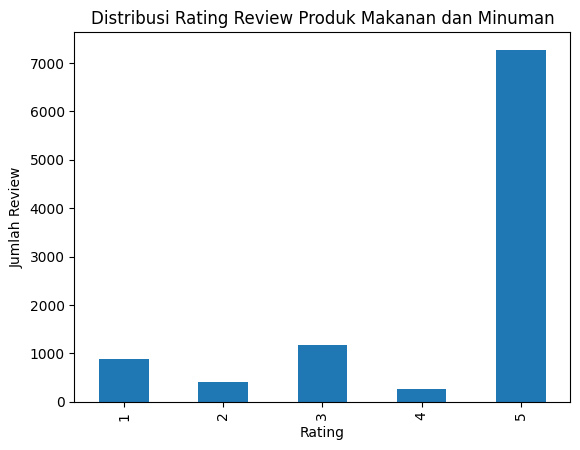

In [21]:
print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns)

print("\nInfo dataset:")
print(df.info())

print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nJumlah duplikasi:")
print(df.duplicated().sum())

print("\nDistribusi rating:")
print(df['rating'].value_counts().sort_index())

print("\nDistribusi kategori:")
print(df['category'].value_counts())

if 'target' in df.columns:
    print("\nDistribusi target:")
    print(df['target'].value_counts())

df['review_length'] = df['review'].astype(str).apply(len)
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

print("\nStatistik panjang review:")
print(df[['review_length', 'word_count']].describe())

df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribusi Rating Review Produk Makanan dan Minuman")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()

# D. Preprocessing

In [22]:
import html

emoji_dict = {
    "😊": "senang",
    "😁": "senang",
    "😍": "suka",
    "🥰": "suka",
    "😭": "kecewa",
    "😢": "sedih",
    "😡": "marah",
    "😤": "kesal",
    "🤩": "senang",
    "🔥": "bagus",
    "👍": "bagus",
    "👎": "jelek",
    "💔": "kecewa",
    "❤️": "suka",
    "❤": "suka",
    "😋": "enak",
    "🤤": "enak",
    "🍜": "makanan",
    "🍔": "makanan",
    "☕": "minuman"
}

def clean_text(text):

    text = str(text).lower()

    # decode html
    text = html.unescape(text)

    # hapus escape sequence
    text = re.sub(
        r'\\n|\\t|\\r|\\b|\\f|\\v',
        ' ',
        text
    )

    text = re.sub(
        r'\\u[0-9a-fA-F]{4}',
        ' ',
        text
    )

    text = re.sub(
        r'\\x[0-9a-fA-F]{2}',
        ' ',
        text
    )

    # hapus url
    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    # konversi emoji
    for emo, meaning in emoji_dict.items():
        text = text.replace(
            emo,
            " " + meaning + " "
        )

    # hapus karakter selain huruf
    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    # normalisasi slang
    words = text.split()

    words = [
        slang_dict.get(w,w)
        for w in words
    ]

    text = " ".join(words)

    # hapus spasi berlebih
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

df = df.dropna(
    subset=["review"]
)

df["clean_text"] = df[
    "review"
].apply(
    clean_text
)

df = df[
    df["clean_text"] != ""
]

print(
    df[
        [
            "review",
            "clean_text",
            "rating"
        ]
    ].head()
)

                                              review  \
0                 Tahu nya enak lembut wangi fresh👍🙏   
1  pengemasan cepat pengiriman jg cepat, harga ok...   
2  dikirim cepat tanpa ada produk yg hancur ataup...   
3  packing aman. mengakomodir note yang diberikan...   
4  Rotinya masih fresh loh pas sampai, terima kas...   

                                          clean_text  rating  
0             tahu nya enak lembut wangi fresh bagus       5  
1  pengemasan cepat pengiriman juga cepat harga o...       5  
2  dikirim cepat tanpa ada produk yang hancur ata...       5  
3  packing aman mengakomodir catatan yang diberik...       5  
4  rotinya masih fresh loh pas sampai terima kasi...       5  


# E. Labeling

In [23]:
df["sentiment"] = df["target"].str.lower()

df["sentiment"] = df["sentiment"].replace({
    "positive": "positif",
    "neutral": "netral",
    "negative": "negatif"
})

print("Distribusi Sentimen:")
print(df["sentiment"].value_counts())

Distribusi Sentimen:
sentiment
positif    7535
negatif    1296
netral     1164
Name: count, dtype: int64


# E1. Label Encoding

In [24]:
sentiment_labels = sorted(df["sentiment"].unique())

label_map = {
    label: i
    for i, label in enumerate(sentiment_labels)
}

sentiment_map = {
    v: k
    for k, v in label_map.items()
}

df["label"] = df["sentiment"].map(label_map)

print("Label Map:")
print(label_map)

Label Map:
{'negatif': 0, 'netral': 1, 'positif': 2}


# F. Split Data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Distribusi Train:")
print(y_train.value_counts())

print("\nDistribusi Test:")
print(y_test.value_counts())

Distribusi Train:
label
2    6028
0    1037
1     931
Name: count, dtype: int64

Distribusi Test:
label
2    1507
0     259
1     233
Name: count, dtype: int64


# G. Tokenizer dan Dataset

In [26]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

lengths = df["clean_text"].str.split().apply(len)

max_len = int(np.percentile(lengths, 95))
max_len = min(max_len, 128)

print("Max Length:", max_len)

train_enc = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=max_len
)

test_enc = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=max_len
)

class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {
            k: torch.tensor(v[idx])
            for k, v in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_enc, y_train)
test_dataset = SentimentDataset(test_enc, y_test)

Max Length: 40


# H. Class Weight

In [27]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([2.5702, 2.8629, 0.4422])


# I. Mertics

In [28]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# J. Custom Trainer dengan Class Weight

In [29]:
class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs[0]

        weights = class_weights.to(logits.device)

        loss_fct = nn.CrossEntropyLoss(weight=weights)

        num_labels = logits.shape[-1]

        loss = loss_fct(
            logits.view(-1, num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

# K. Training

In [30]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(sentiment_labels),
    id2label={
        idx: label
        for idx, label in enumerate(sentiment_labels)
    },
    label2id={
        label: idx
        for idx, label in enumerate(sentiment_labels)
    },
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir="./results_makanan_minuman_clean_v2",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_steps=100,

    warmup_steps=300,

    weight_decay=0.01,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

eval_result = trainer.evaluate()

print("\nHASIL EVALUASI:")
print(eval_result)

best_model = trainer.model

best_result = {
    "learning_rate": 2e-5,
    "batch_size": 16,
    "epoch": 5,
    "warmup_steps": 300,
    "accuracy": eval_result["eval_accuracy"],
    "f1_weighted": eval_result["eval_f1_weighted"],
    "f1_macro": eval_result["eval_f1_macro"]
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.622353,0.562763,0.858429,0.862848,0.702150
2,0.522170,0.557471,0.849425,0.862089,0.712402
3,0.344842,0.638689,0.871436,0.876852,0.729728
4,0.182558,0.927470,0.872436,0.877577,0.728170
5,0.088724,1.080185,0.880940,0.882048,0.734201


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


HASIL EVALUASI:
{'eval_loss': 1.080184817314148, 'eval_accuracy': 0.8809404702351176, 'eval_f1_weighted': 0.8820478905314852, 'eval_f1_macro': 0.7342013141302045, 'eval_runtime': 4.763, 'eval_samples_per_second': 419.69, 'eval_steps_per_second': 13.227, 'epoch': 5.0}


# L. Evaluasi Model Terbaik

In [31]:
best_model = trainer.model
best_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

all_preds = []
all_labels = []

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = best_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(sentiment_labels))),
    target_names=sentiment_labels
))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_true, y_pred))

print("\nF1-SCORE PER CLASS:")
f1_per_class = f1_score(
    y_true,
    y_pred,
    average=None
)

for label, score in zip(sentiment_labels, f1_per_class):
    status = "AMAN" if score >= 0.75 else "PERLU DITINGKATKAN"
    print(f"{label:10s}: F1 = {score:.4f} | {status}")

print(f"\nAccuracy   : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1   : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_true, y_pred, average='weighted'):.4f}")


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     negatif       0.68      0.67      0.68       259
      netral       0.54      0.58      0.56       233
     positif       0.97      0.96      0.97      1507

    accuracy                           0.88      1999
   macro avg       0.73      0.74      0.73      1999
weighted avg       0.88      0.88      0.88      1999


CONFUSION MATRIX:
[[ 174   70   15]
 [  70  134   29]
 [  12   42 1453]]

F1-SCORE PER CLASS:
negatif   : F1 = 0.6757 | PERLU DITINGKATKAN
netral    : F1 = 0.5595 | PERLU DITINGKATKAN
positif   : F1 = 0.9674 | AMAN

Accuracy   : 0.8809
Macro F1   : 0.7342
Weighted F1: 0.8820


# M.  Error Analysis

In [32]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_true,
    "pred_label": y_pred
})

error_df["true_sentiment"] = error_df["true_label"].map(sentiment_map)
error_df["pred_sentiment"] = error_df["pred_label"].map(sentiment_map)

wrong_predictions = error_df[
    error_df["true_sentiment"] != error_df["pred_sentiment"]
]

print("\nJUMLAH SALAH PREDIKSI:", len(wrong_predictions))
print(wrong_predictions.head(10))

print("\nPola kesalahan prediksi:")
print(
    wrong_predictions
    .groupby(["true_sentiment", "pred_sentiment"])
    .size()
)


JUMLAH SALAH PREDIKSI: 238
                                                 text  true_label  pred_label  \
8   bukan potongan daging rendang tidak kotak dan ...           1           0   
9                                 barang tidak sampai           1           0   
14  di coba tetes ke kakak perempuan dan aftertase...           0           2   
25                              rasanya no bangeeeeet           0           1   
46  sekedar masukan harus nya kurir kalau tidak ad...           1           2   
50  beras nya mudah basi dibandingkan beras coklat...           1           0   
52                                      rasa nya enak           1           2   
63  pemesanan sampai barang tiba tidak sampai jam ...           2           0   
64                                              bagus           2           1   
71  keseluruhan rasanya enak tidak terlalu manis s...           1           2   

   true_sentiment pred_sentiment  
8          netral        negatif  
9         

# N. Inferene

In [33]:
def predict_sentiment(text, show_confidence=False):

    text_clean = clean_text(text)

    encoding = tokenizer(
        [text_clean],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_len
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    best_model.to(device)
    best_model.eval()

    encoding = {
        k: v.to(device)
        for k, v in encoding.items()
    }

    with torch.no_grad():
        output = best_model(**encoding)

    pred = torch.argmax(
        output.logits,
        dim=1
    ).item()

    if show_confidence:
        probs = torch.softmax(
            output.logits,
            dim=1
        ).squeeze().tolist()

        print("\nConfidence per kelas:")

        for label, prob in zip(sentiment_labels, probs):
            print(f"{label:10s}: {prob:.2%}")

    return sentiment_map[pred]


test_samples = [
    "Rasanya enak banget, kemasan aman dan pengiriman cepat",
    "Rasanya biasa saja, tidak terlalu enak tapi masih bisa dimakan",
    "Makanannya basi, kemasan bocor, dan sangat mengecewakan"
]

print("\nHASIL INFERENCE:")

for sample in test_samples:
    hasil = predict_sentiment(
        sample,
        show_confidence=True
    )

    print("\nTeks     :", sample)
    print("Sentimen :", hasil)
    print("-" * 50)


HASIL INFERENCE:

Confidence per kelas:
negatif   : 0.07%
netral    : 0.05%
positif   : 99.88%

Teks     : Rasanya enak banget, kemasan aman dan pengiriman cepat
Sentimen : positif
--------------------------------------------------

Confidence per kelas:
negatif   : 0.05%
netral    : 0.71%
positif   : 99.24%

Teks     : Rasanya biasa saja, tidak terlalu enak tapi masih bisa dimakan
Sentimen : positif
--------------------------------------------------

Confidence per kelas:
negatif   : 99.76%
netral    : 0.13%
positif   : 0.11%

Teks     : Makanannya basi, kemasan bocor, dan sangat mengecewakan
Sentimen : negatif
--------------------------------------------------


# O. Simpan Model ke .pkl

In [34]:
SAVE_DIR = "/kaggle/working/model_sentiment_makanan_minuman"

os.makedirs(SAVE_DIR, exist_ok=True)

best_model_cpu = best_model.to("cpu")

best_model_cpu.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

best_result = {
    "learning_rate": 1e-5,
    "batch_size": 16,
    "accuracy": accuracy_score(y_true, y_pred),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "f1_macro": f1_score(y_true, y_pred, average="macro")
}

model_bundle = {
    "model_state": best_model_cpu.state_dict(),
    "config": best_model_cpu.config,
    "tokenizer": tokenizer,
    "label_map": label_map,
    "sentiment_map": sentiment_map,
    "max_len": max_len,
    "best_experiment": best_result
}

file_path = "/kaggle/working/model_sentiment_makanan_minuman_indobert.pkl"

with open(file_path, "wb") as f:
    pickle.dump(model_bundle, f)

df_save = df[
    [
        "review",
        "clean_text",
        "rating",
        "sentiment",
        "label"
    ]
]

df_save.to_csv(
    "/kaggle/working/clean_dataset_sentiment_makanan_minuman.csv",
    index=False
)

print("\nMODEL SAVED")
print("File model:", file_path)
print("File dataset bersih: /kaggle/working/clean_dataset_sentiment_makanan_minuman.csv")

print("\nDaftar file di /kaggle/working:")
print(os.listdir("/kaggle/working"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MODEL SAVED
File model: /kaggle/working/model_sentiment_makanan_minuman_indobert.pkl
File dataset bersih: /kaggle/working/clean_dataset_sentiment_makanan_minuman.csv

Daftar file di /kaggle/working:
['clean_dataset_sentiment_makanan_minuman.csv', 'model_sentiment_makanan_minuman', 'model_sentiment_makanan_minuman_indobert.pkl', '.virtual_documents', 'results_makanan_minuman_clean_v2', 'results_makanan_minuman_best']
